In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler

## Load data

Загрузим датасет FD001, а также добавим имена колонкам

In [17]:
file_path = '../data/raw/train_FD001.txt'
df = pd.read_csv(file_path, sep=' ', header=None)
df = df.drop(columns=df.columns[-2:])
col_names = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df.columns = col_names
df.head(10)

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   op1     20631 non-null  float64
 3   op2     20631 non-null  float64
 4   op3     20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22

In [19]:
df.describe()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## EDA

Посмотрим на распределение жизней двигателей

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64
   unit  cycle
0     1    192
1     2    287
2     3    179
3     4    189
4     5    269


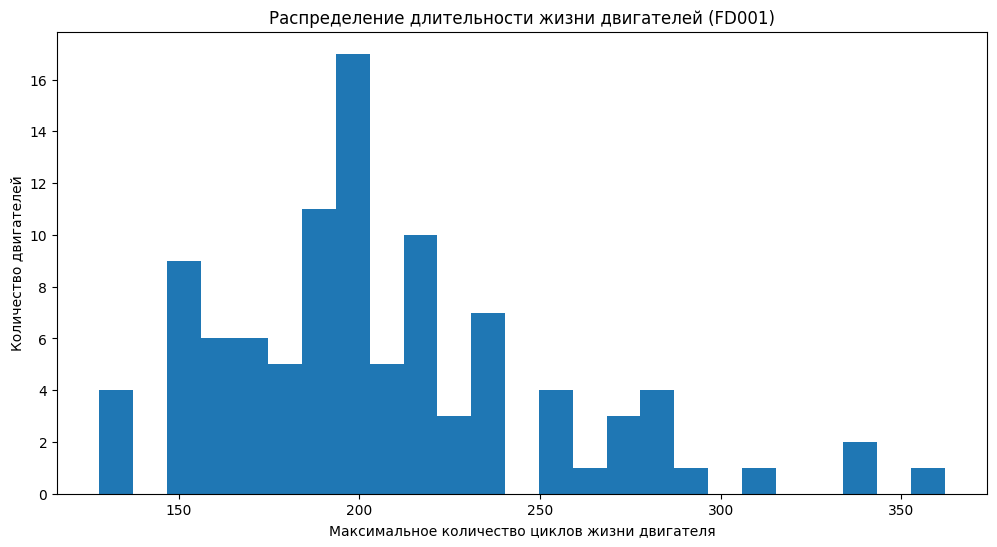

In [20]:
life_cycles = df.groupby('unit')['cycle'].max().reset_index()
print(life_cycles.cycle.describe())
print(life_cycles.head())

plt.figure(figsize=(12,6))
plt.hist(life_cycles['cycle'], bins=25)
plt.xlabel('Максимальное количество циклов жизни двигателя')
plt.ylabel('Количество двигателей')
plt.title('Распределение длительности жизни двигателей (FD001)')
plt.show()

Добавим RUL = max_cycle - cur_cycle

In [21]:
df['RUL'] = df.groupby('unit')['cycle'].transform('max') - df['cycle']
print(df[['unit', 'cycle', 'RUL']].head())

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187


Посмотрим на поведение всех сенсоров для первого двигателя

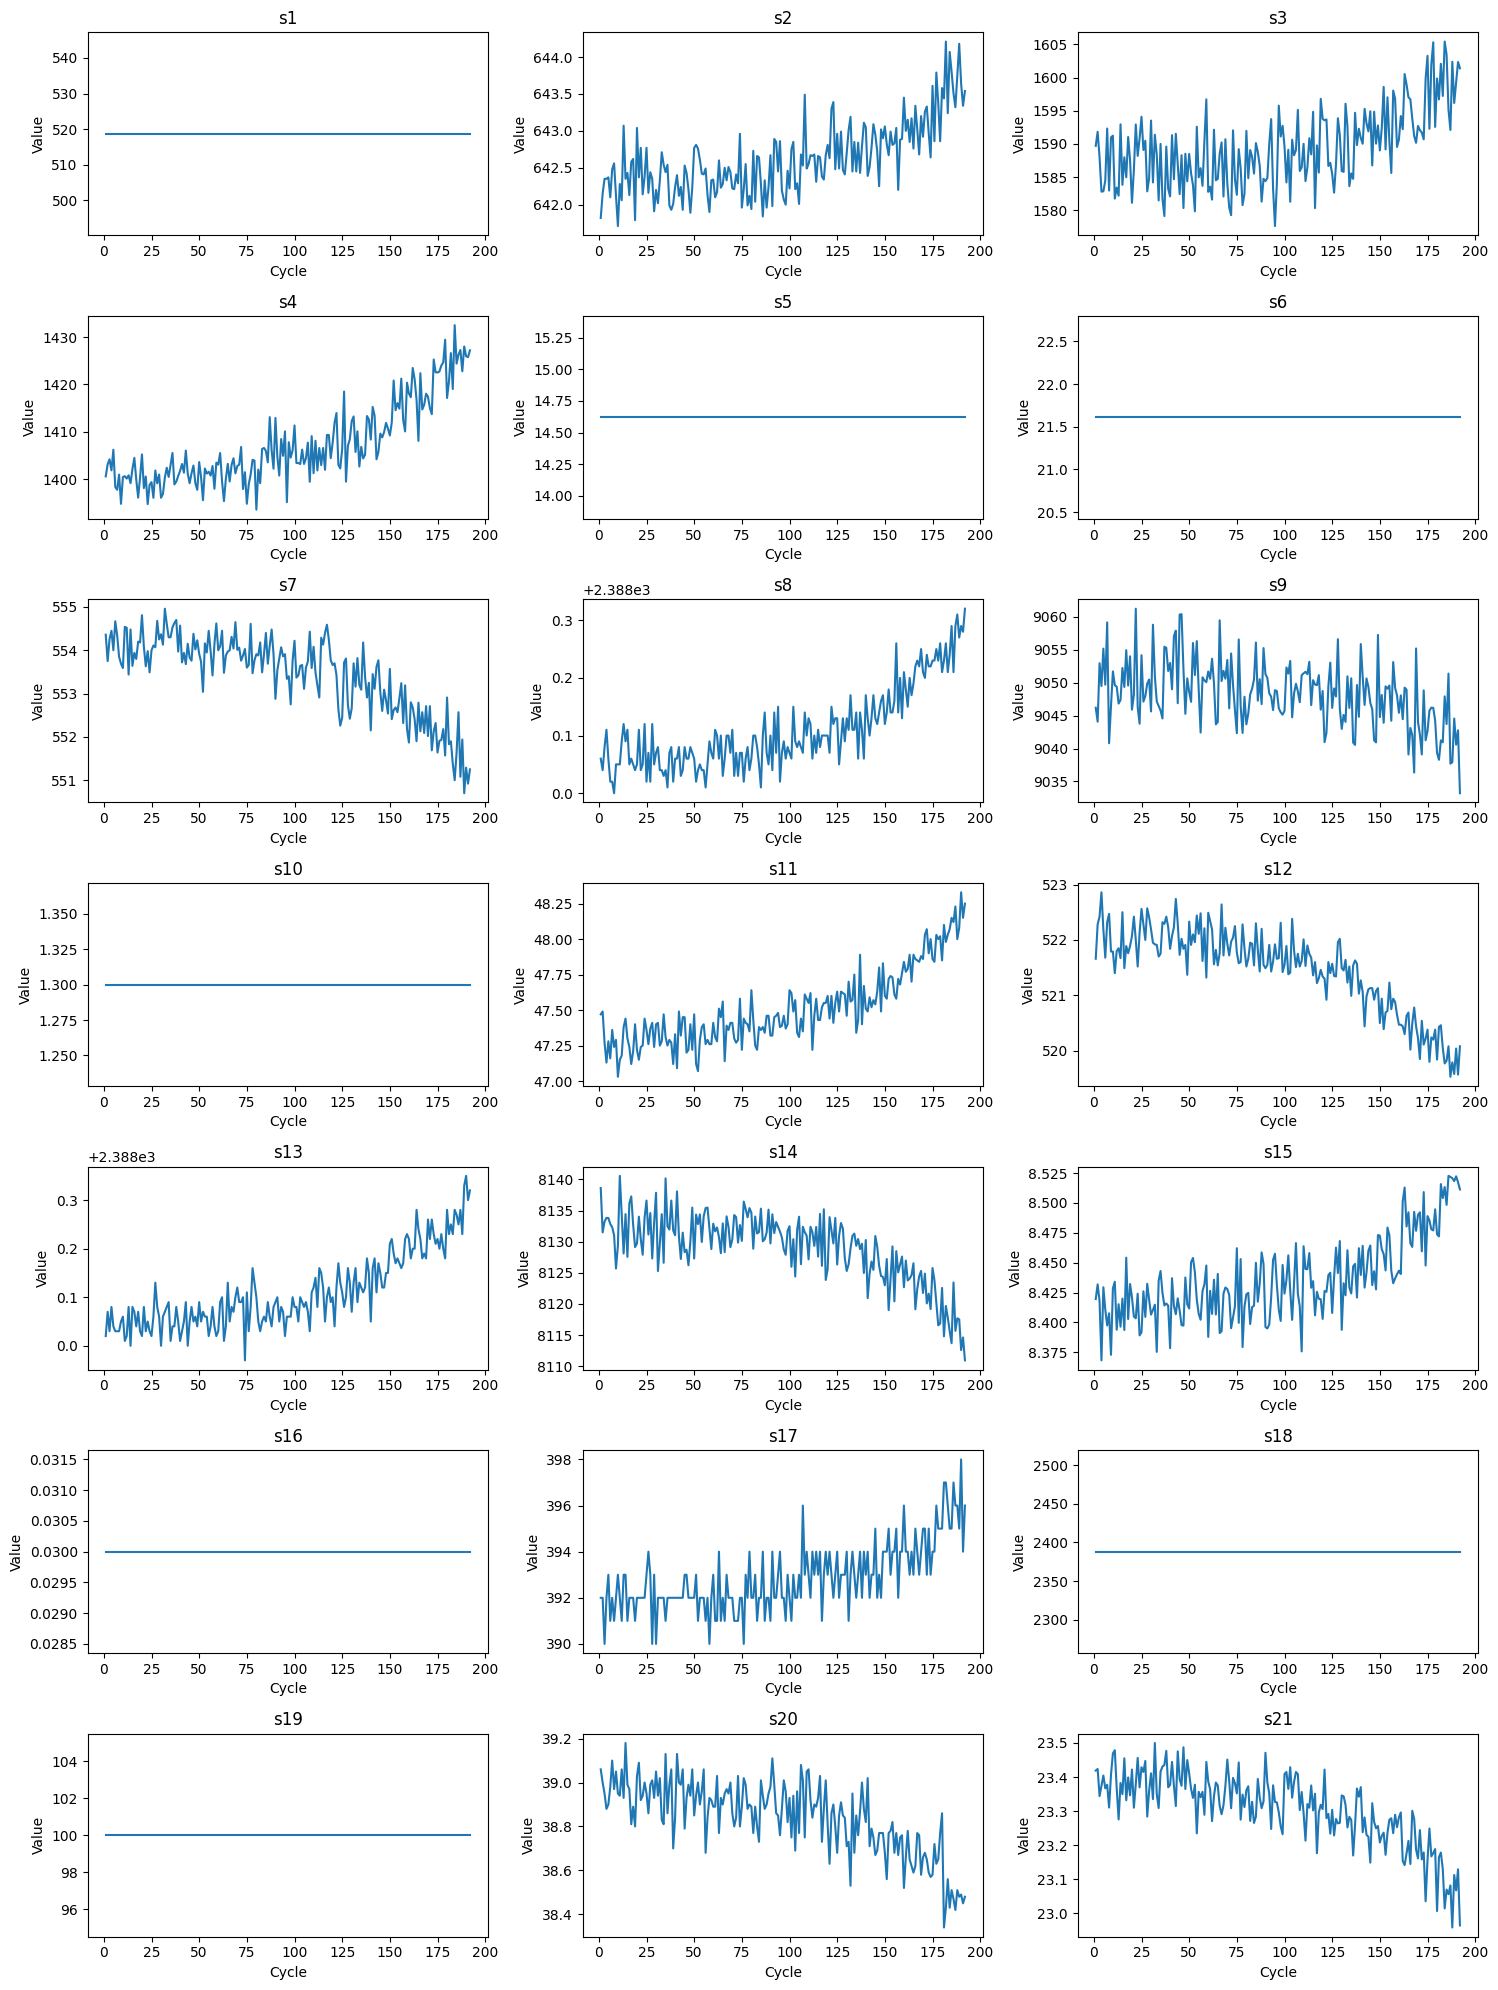

In [22]:
unit_to_plot = 1
unit_data = df[df['unit'] == unit_to_plot]

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

for i in range(21):
    col = f's{i+1}'
    axes[i].plot(unit_data['cycle'], unit_data[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

Видим, что сенсоры s1, s5, s6, s10, s16, s18 и s19 не несут никакой информации и сохраняют постоянное значение во время всего эксперимента.

Посмотрим, сохраняется ли такая тенденция и для других двигателей.

In [23]:
sensor_cols = [f's{i}' for i in range(1,22)]
sensor_std_per_unit = df.groupby('unit')[sensor_cols].std()
mean_std_across_units = sensor_std_per_unit.mean().sort_values()
print(mean_std_across_units)

s1      0.000000
s5      0.000000
s16     0.000000
s10     0.000000
s19     0.000000
s18     0.000000
s6      0.000959
s15     0.034465
s8      0.056596
s13     0.057271
s21     0.099550
s20     0.166420
s11     0.237445
s2      0.462850
s12     0.648178
s7      0.786467
s17     1.450997
s3      5.788760
s4      8.118497
s14    11.804007
s9     14.189053
dtype: float64


Есть сенсоры, которые стоит удалить

## Preprocessing

### 1. Удаление неинформативных сенсоров

In [25]:
sensor_cols = [f's{i}' for i in range(1,22)]
mean_std_across_units = df.groupby('unit')[sensor_cols].std().mean().sort_values()

sensors_to_drop = mean_std_across_units[mean_std_across_units < 0.001].index.tolist()
print(f"Сенсоры с постоянными значениями: {sensors_to_drop}")

df = df.drop(columns=sensors_to_drop)
print(f"Осталось сенсоров: {len(df.columns) - 5}")

Сенсоры с постоянными значениями: ['s1', 's5', 's16', 's10', 's19', 's18', 's6']
Осталось сенсоров: 15


### 2. RUL clipping

Не будем предсказывать большие числа RUL, например, 150. А сконцентрируемся на диапзоне поменьше, т. е. ограничим до 130.

In [26]:
RUL_THRESHOLD = 130
df['RUL_clipped'] = df['RUL'].clip(upper=RUL_THRESHOLD)
print(df[['unit', 'cycle', 'RUL', 'RUL_clipped']].head())

   unit  cycle  RUL  RUL_clipped
0     1      1  191          130
1     1      2  190          130
2     1      3  189          130
3     1      4  188          130
4     1      5  187          130


### 3. Извлечение признаков

Нужно преобразовать временные ряды в набор признаков (для клас. моделей). Для этого воспользуемся скользящим окном, для каждого окна будем вычислять статистики.

In [27]:
feature_cols = ['op1', 'op2', 'op3'] + [col for col in df.columns if col.startswith('s')]

def create_feats(group, window_size=30):
    features = []
    for start in range(0, len(group) - window_size + 1):
        window = group.iloc[start:start + window_size]

        # Статистики для каждого окна
        stats = []
        for col in feature_cols:
            stats.append(window[col].mean())
            stats.append(window[col].std())
            stats.append(window[col].min())
            stats.append(window[col].max())
            stats.append(window[col].iloc[-1] - window[col].iloc[0])

        # RUL в последний момент окна
        rul = window['RUL_clipped'].iloc[-1]
        features.append(stats + [rul])

    return pd.DataFrame(features)

In [28]:
window_size = 30
all_features = []

for unit_id, group in df.groupby('unit'):
    group = group.sort_values('cycle')
    unit_features = create_feats(group, window_size)
    all_features.append(unit_features)

features_df = pd.concat(all_features, ignore_index=True)

stat_cols = []
for col in feature_cols:
    stat_cols += [f'{col}_mean', f'{col}_std', f'{col}_min', f'{col}_max', f'{col}_delta']

features_df.columns = stat_cols + ['RUL']

print(features_df.head())
print(features_df.shape)

   op1_mean   op1_std  op1_min  op1_max  op1_delta  op2_mean   op2_std  \
0 -0.000553  0.002199  -0.0043   0.0034    -0.0015  0.000007  0.000269   
1 -0.000483  0.002228  -0.0043   0.0034    -0.0005  0.000037  0.000272   
2 -0.000530  0.002191  -0.0043   0.0034     0.0048  0.000037  0.000272   
3 -0.000527  0.002185  -0.0043   0.0034    -0.0049  0.000013  0.000279   
4 -0.000500  0.002205  -0.0043   0.0034     0.0034  0.000010  0.000280   

   op2_min  op2_max  op2_delta  ...   s20_std  s20_min  s20_max  s20_delta  \
0  -0.0004   0.0005     0.0004  ...  0.084443     38.8    39.18      -0.01   
1  -0.0004   0.0005     0.0008  ...  0.082993     38.8    39.18      -0.06   
2  -0.0004   0.0005    -0.0006  ...  0.083333     38.8    39.18       0.07   
3  -0.0004   0.0005    -0.0004  ...  0.087088     38.8    39.18      -0.05   
4  -0.0004   0.0005     0.0001  ...  0.090331     38.8    39.18      -0.09   

    s21_mean   s21_std  s21_min  s21_max  s21_delta  RUL  
0  23.385460  0.052695  23.

In [64]:
features_df.describe()

,op1_mean,op1_std,op1_min,op1_max,op1_delta,op2_mean,op2_std,op2_min,op2_max,op2_delta,...,s20_std,s20_min,s20_max,s20_delta,s21_mean,s21_std,s21_min,s21_max,s21_delta,RUL
count,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,1.773100e+04,17731.000000,17731.000000,17731.000000,17731.000000,...,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000
mean,-0.000016,0.002171,-0.004529,0.004403,0.000002,2.792661e-06,0.000289,-0.000463,0.000471,0.000002,...,0.103345,38.617297,39.042625,-0.062047,23.298844,0.061279,23.172725,23.422627,-0.037637,82.065817
std,0.000388,0.000285,0.001043,0.001057,0.003115,6.787945e-05,0.000025,0.000058,0.000061,0.000410,...,0.013924,0.140490,0.129626,0.154185,0.076107,0.008448,0.084352,0.077730,0.091327,43.347959
min,-0.001590,0.001247,-0.008700,0.001600,-0.012200,-2.133333e-04,0.000180,-0.000600,0.000200,-0.001000,...,0.063169,38.140000,38.630000,-0.660000,23.088323,0.027879,22.894200,23.186500,-0.389800,0.000000
25%,-0.000273,0.001978,-0.005100,0.003700,-0.002100,-4.333333e-05,0.000272,-0.000500,0.000400,-0.000300,...,0.093726,38.530000,38.950000,-0.160000,23.250203,0.055596,23.117500,23.367700,-0.098400,44.000000
50%,-0.000003,0.002166,-0.004400,0.004300,0.000000,9.035018e-22,0.000289,-0.000500,0.000500,0.000000,...,0.102442,38.620000,39.050000,-0.060000,23.302837,0.060953,23.178800,23.423400,-0.036600,88.000000
75%,0.000247,0.002364,-0.003800,0.005000,0.002100,5.000000e-05,0.000306,-0.000400,0.000500,0.000300,...,0.112170,38.720000,39.140000,0.040000,23.357830,0.066518,23.233600,23.479700,0.024100,130.000000
max,0.001253,0.003291,-0.001800,0.008700,0.011500,2.466667e-04,0.000379,-0.000100,0.000600,0.001000,...,0.170425,38.950000,39.430000,0.510000,23.457717,0.097043,23.353100,23.618400,0.321500,130.000000


Признаки не скейлим / нормализуем, при необходимости будем производить перед обучением

### 5. Подготовка данных для нейросетевых моделей

coming soon... add scaling/norm

## Какие сенсоры бесполезны в других наборах?

### 1. FD002

In [70]:
file_path = '../data/raw/train_FD002.txt'
df = pd.read_csv(file_path, sep=' ', header=None)
df = df.drop(columns=df.columns[-2:])
col_names = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df.columns = col_names
df.head(10)

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286
5,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,164.27,2028.01,7868.87,10.8912,0.02,306,1915,84.93,14.28,8.5590
6,1,7,42.0043,0.8409,100.0,445.00,549.74,1347.45,1127.19,3.91,...,130.49,2387.69,8075.54,9.3753,0.02,330,2212,100.00,10.62,6.4227
7,1,8,20.0020,0.7002,100.0,491.19,607.44,1481.69,1252.36,9.35,...,315.11,2387.99,8049.26,9.2369,0.02,365,2324,100.00,24.33,14.7989
8,1,9,41.9995,0.8407,100.0,445.00,549.33,1348.23,1127.45,3.91,...,130.97,2387.62,8065.78,9.3878,0.02,331,2212,100.00,10.69,6.3802
9,1,10,42.0011,0.8400,100.0,445.00,549.33,1356.40,1127.11,3.91,...,130.50,2387.62,8069.11,9.3957,0.02,329,2212,100.00,10.57,6.2847


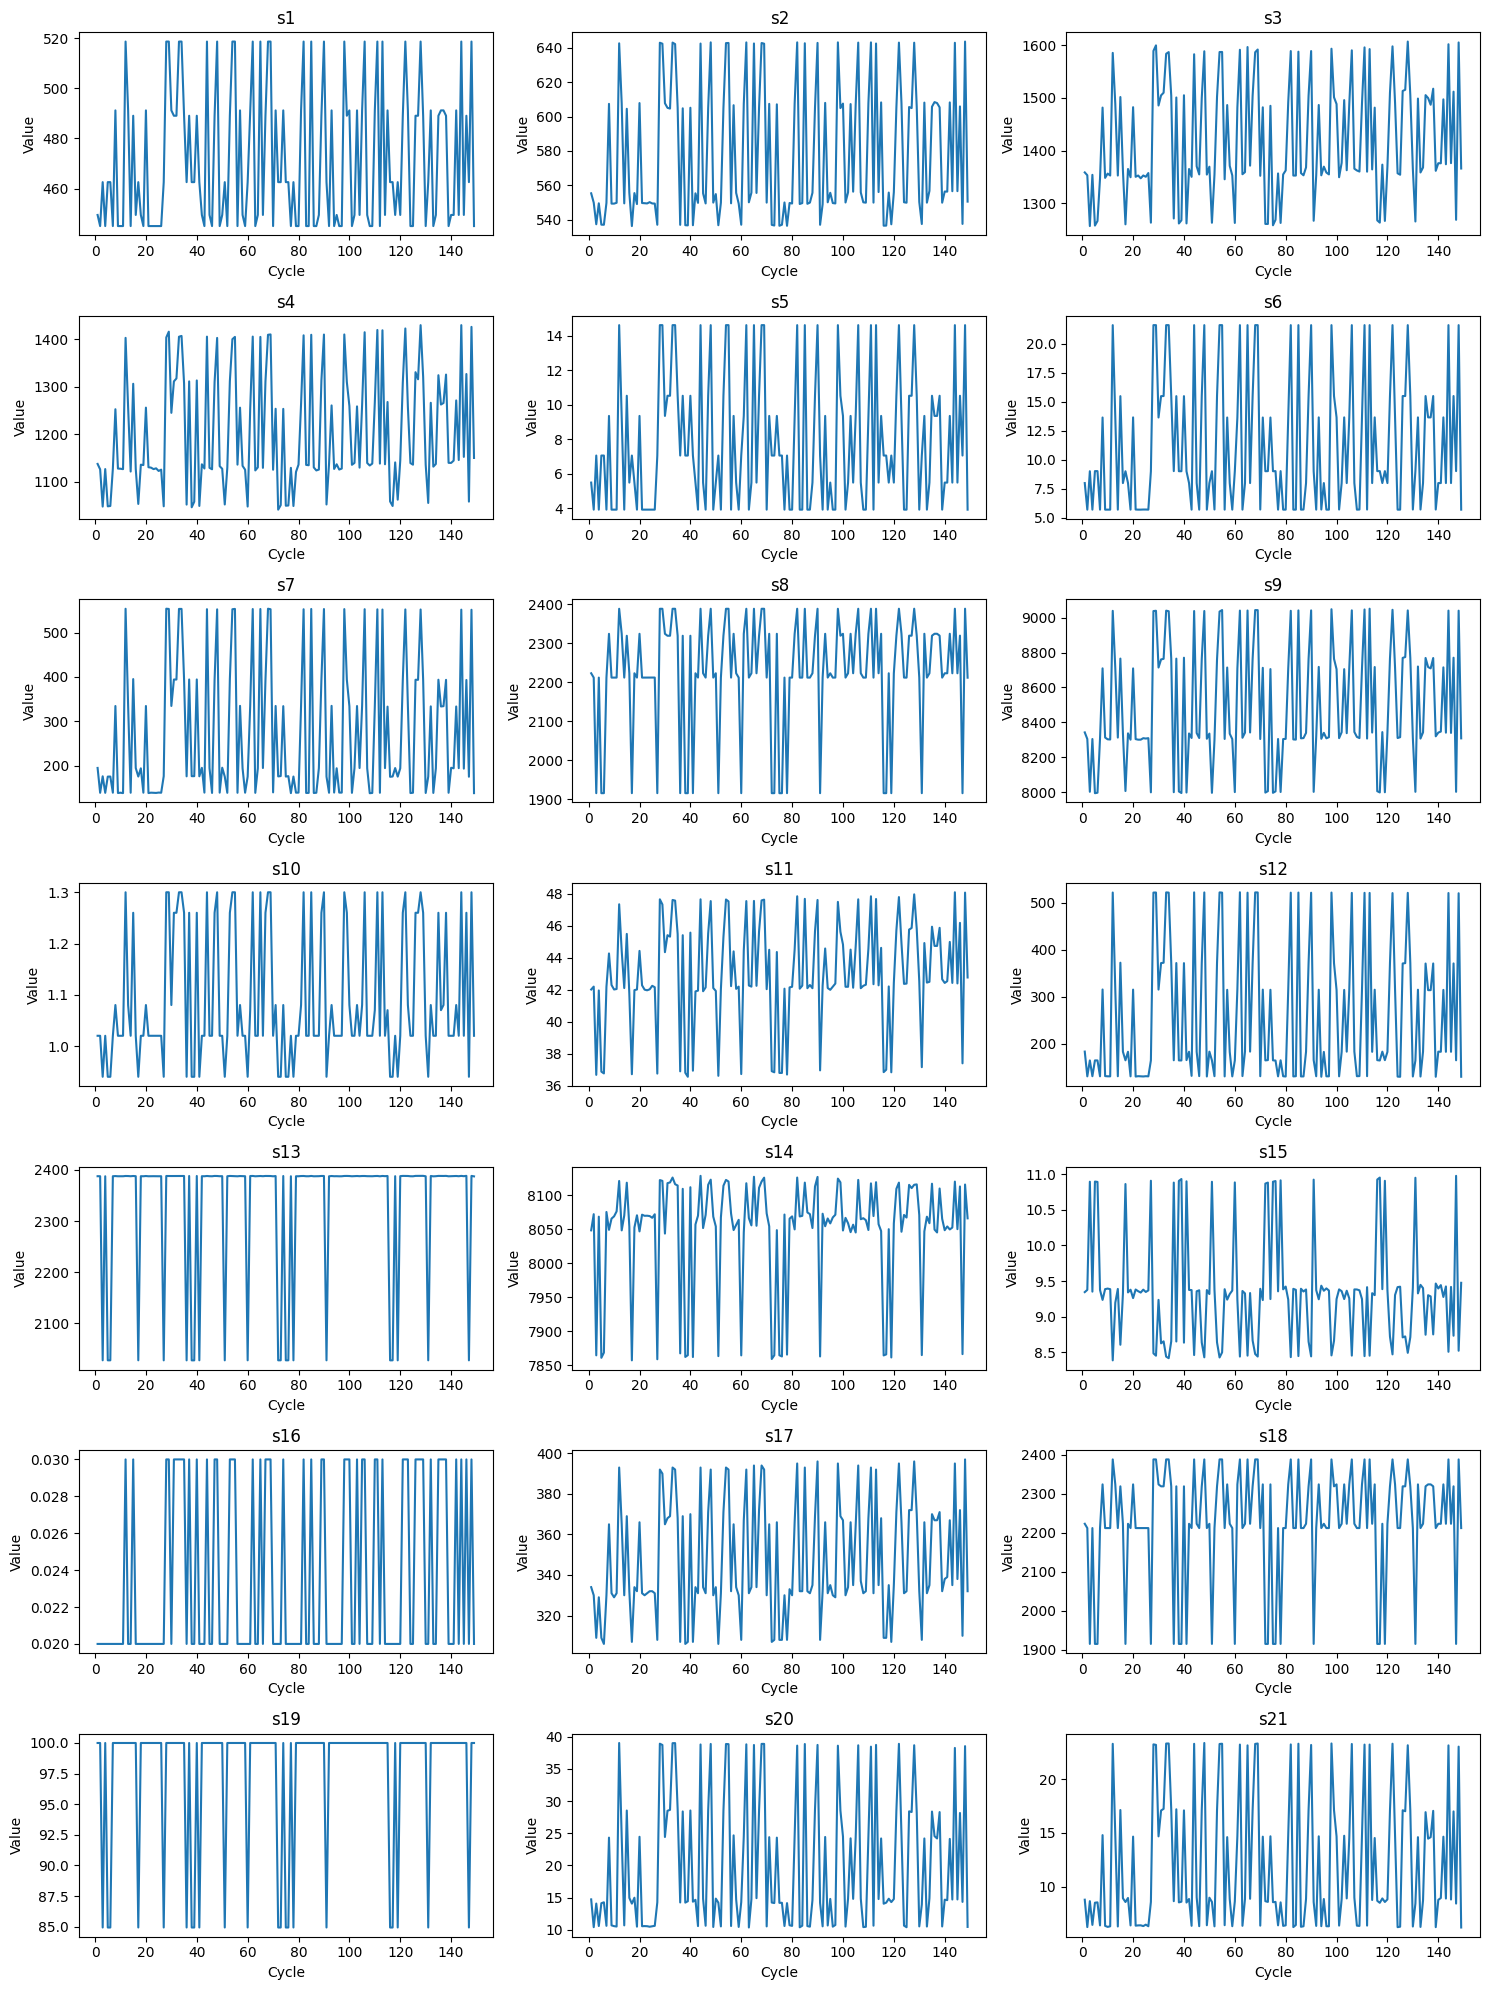

In [71]:
unit_to_plot = 1
unit_data = df[df['unit'] == unit_to_plot]

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

for i in range(21):
    col = f's{i+1}'
    axes[i].plot(unit_data['cycle'], unit_data[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

In [69]:
sensor_cols = [f's{i}' for i in range(1,22)]
sensor_std_per_unit = df.groupby('unit')[sensor_cols].std()
mean_std_across_units = sensor_std_per_unit.mean().sort_values()
print(mean_std_across_units)

s16      0.004713
s10      0.127553
s15      0.748950
s11      3.232421
s5       3.616254
s19      5.358599
s6       5.435532
s21      5.925231
s20      9.875423
s1      26.413509
s17     27.774112
s2      37.325360
s14     84.055045
s3     106.035197
s4     119.202814
s13    127.939458
s12    137.751497
s8     145.183502
s18    145.296614
s7     146.102793
s9     335.831498
dtype: float64


В этом наборе все сенсоры полезны

### 2. FD003

In [72]:
file_path = '../data/raw/train_FD003.txt'
df = pd.read_csv(file_path, sep=' ', header=None)
df = df.drop(columns=df.columns[-2:])
col_names = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df.columns = col_names
df.head(10)

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583
5,1,6,0.0011,-0.0005,100.0,518.67,642.24,1584.09,1400.01,14.62,...,522.42,2388.02,8144.92,8.4152,0.03,393,2388,100.0,38.92,23.4281
6,1,7,-0.0038,0.0002,100.0,518.67,642.58,1585.61,1401.09,14.62,...,522.46,2388.02,8147.05,8.3842,0.03,391,2388,100.0,38.84,23.4087
7,1,8,-0.0007,-0.0005,100.0,518.67,642.32,1588.32,1397.08,14.62,...,522.10,2387.97,8157.34,8.4190,0.03,391,2388,100.0,39.05,23.4590
8,1,9,-0.0026,0.0000,100.0,518.67,641.64,1587.81,1406.51,14.62,...,521.83,2388.01,8147.20,8.4091,0.03,392,2388,100.0,38.99,23.4693
9,1,10,0.0019,-0.0002,100.0,518.67,642.42,1587.39,1402.25,14.62,...,521.96,2387.99,8152.86,8.3987,0.03,391,2388,100.0,38.94,23.4781


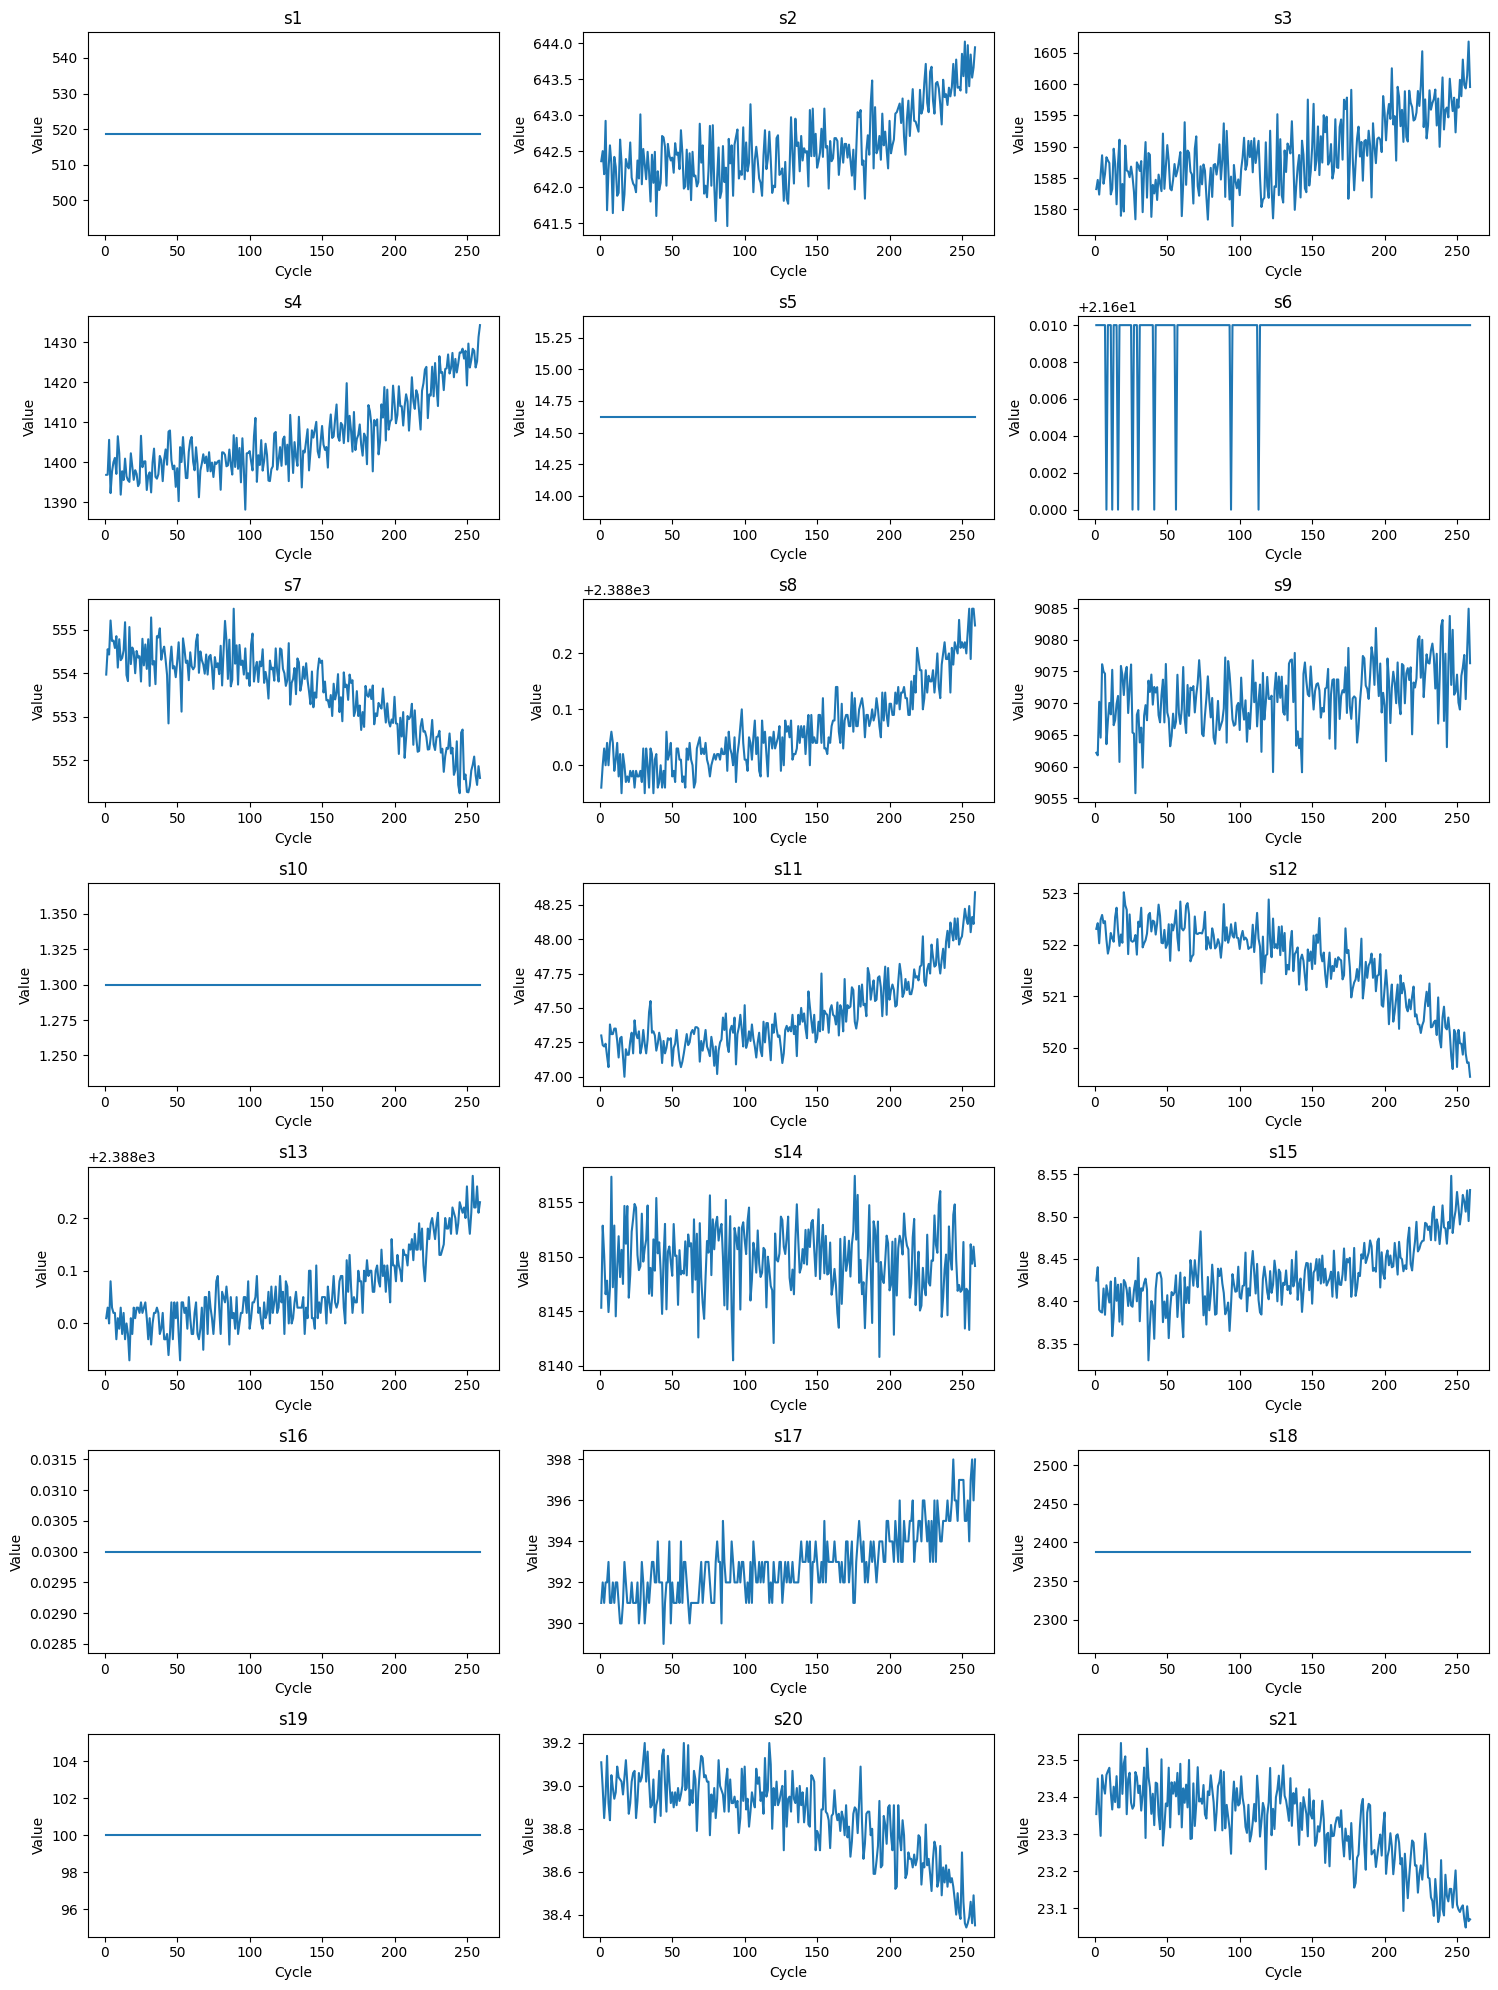

In [73]:
unit_to_plot = 1
unit_data = df[df['unit'] == unit_to_plot]

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

for i in range(21):
    col = f's{i+1}'
    axes[i].plot(unit_data['cycle'], unit_data[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

In [74]:
sensor_cols = [f's{i}' for i in range(1,22)]
sensor_std_per_unit = df.groupby('unit')[sensor_cols].std()
mean_std_across_units = sensor_std_per_unit.mean().sort_values()
print(mean_std_across_units)

s1      0.000000
s5      0.000000
s16     0.000000
s18     0.000000
s19     0.000000
s10     0.001948
s6      0.002786
s15     0.039164
s21     0.103708
s8      0.106337
s13     0.106468
s20     0.173994
s11     0.255863
s2      0.457095
s17     1.554205
s12     1.922714
s7      2.065488
s3      6.089602
s4      8.351579
s14    12.229560
s9     15.249438
dtype: float64


В этом наборе картина схожа с первым набором

### 3. FD004

In [76]:
file_path = '../data/raw/train_FD004.txt'
df = pd.read_csv(file_path, sep=' ', header=None)
df = df.drop(columns=df.columns[-2:])
col_names = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df.columns = col_names
df.head(10)

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
5,1,6,34.9996,0.8400,100.0,449.44,554.77,1352.87,1117.01,5.48,...,181.90,2387.87,8054.10,9.3346,0.02,330,2223,100.00,14.91,8.9057
6,1,7,0.0019,0.0001,100.0,518.67,641.83,1583.47,1393.89,14.62,...,520.48,2387.89,8127.92,8.3960,0.03,391,2388,100.00,38.93,23.4578
7,1,8,41.9981,0.8400,100.0,445.00,549.05,1344.16,1110.77,3.91,...,129.65,2387.97,8075.99,9.3679,0.02,329,2212,100.00,10.55,6.2787
8,1,9,42.0016,0.8400,100.0,445.00,549.55,1342.85,1101.67,3.91,...,129.65,2388.00,8071.13,9.3384,0.02,328,2212,100.00,10.63,6.3055
9,1,10,25.0019,0.6217,60.0,462.54,536.35,1251.91,1041.37,7.05,...,164.08,2028.13,7869.41,10.9141,0.02,305,1915,84.93,14.34,8.6119


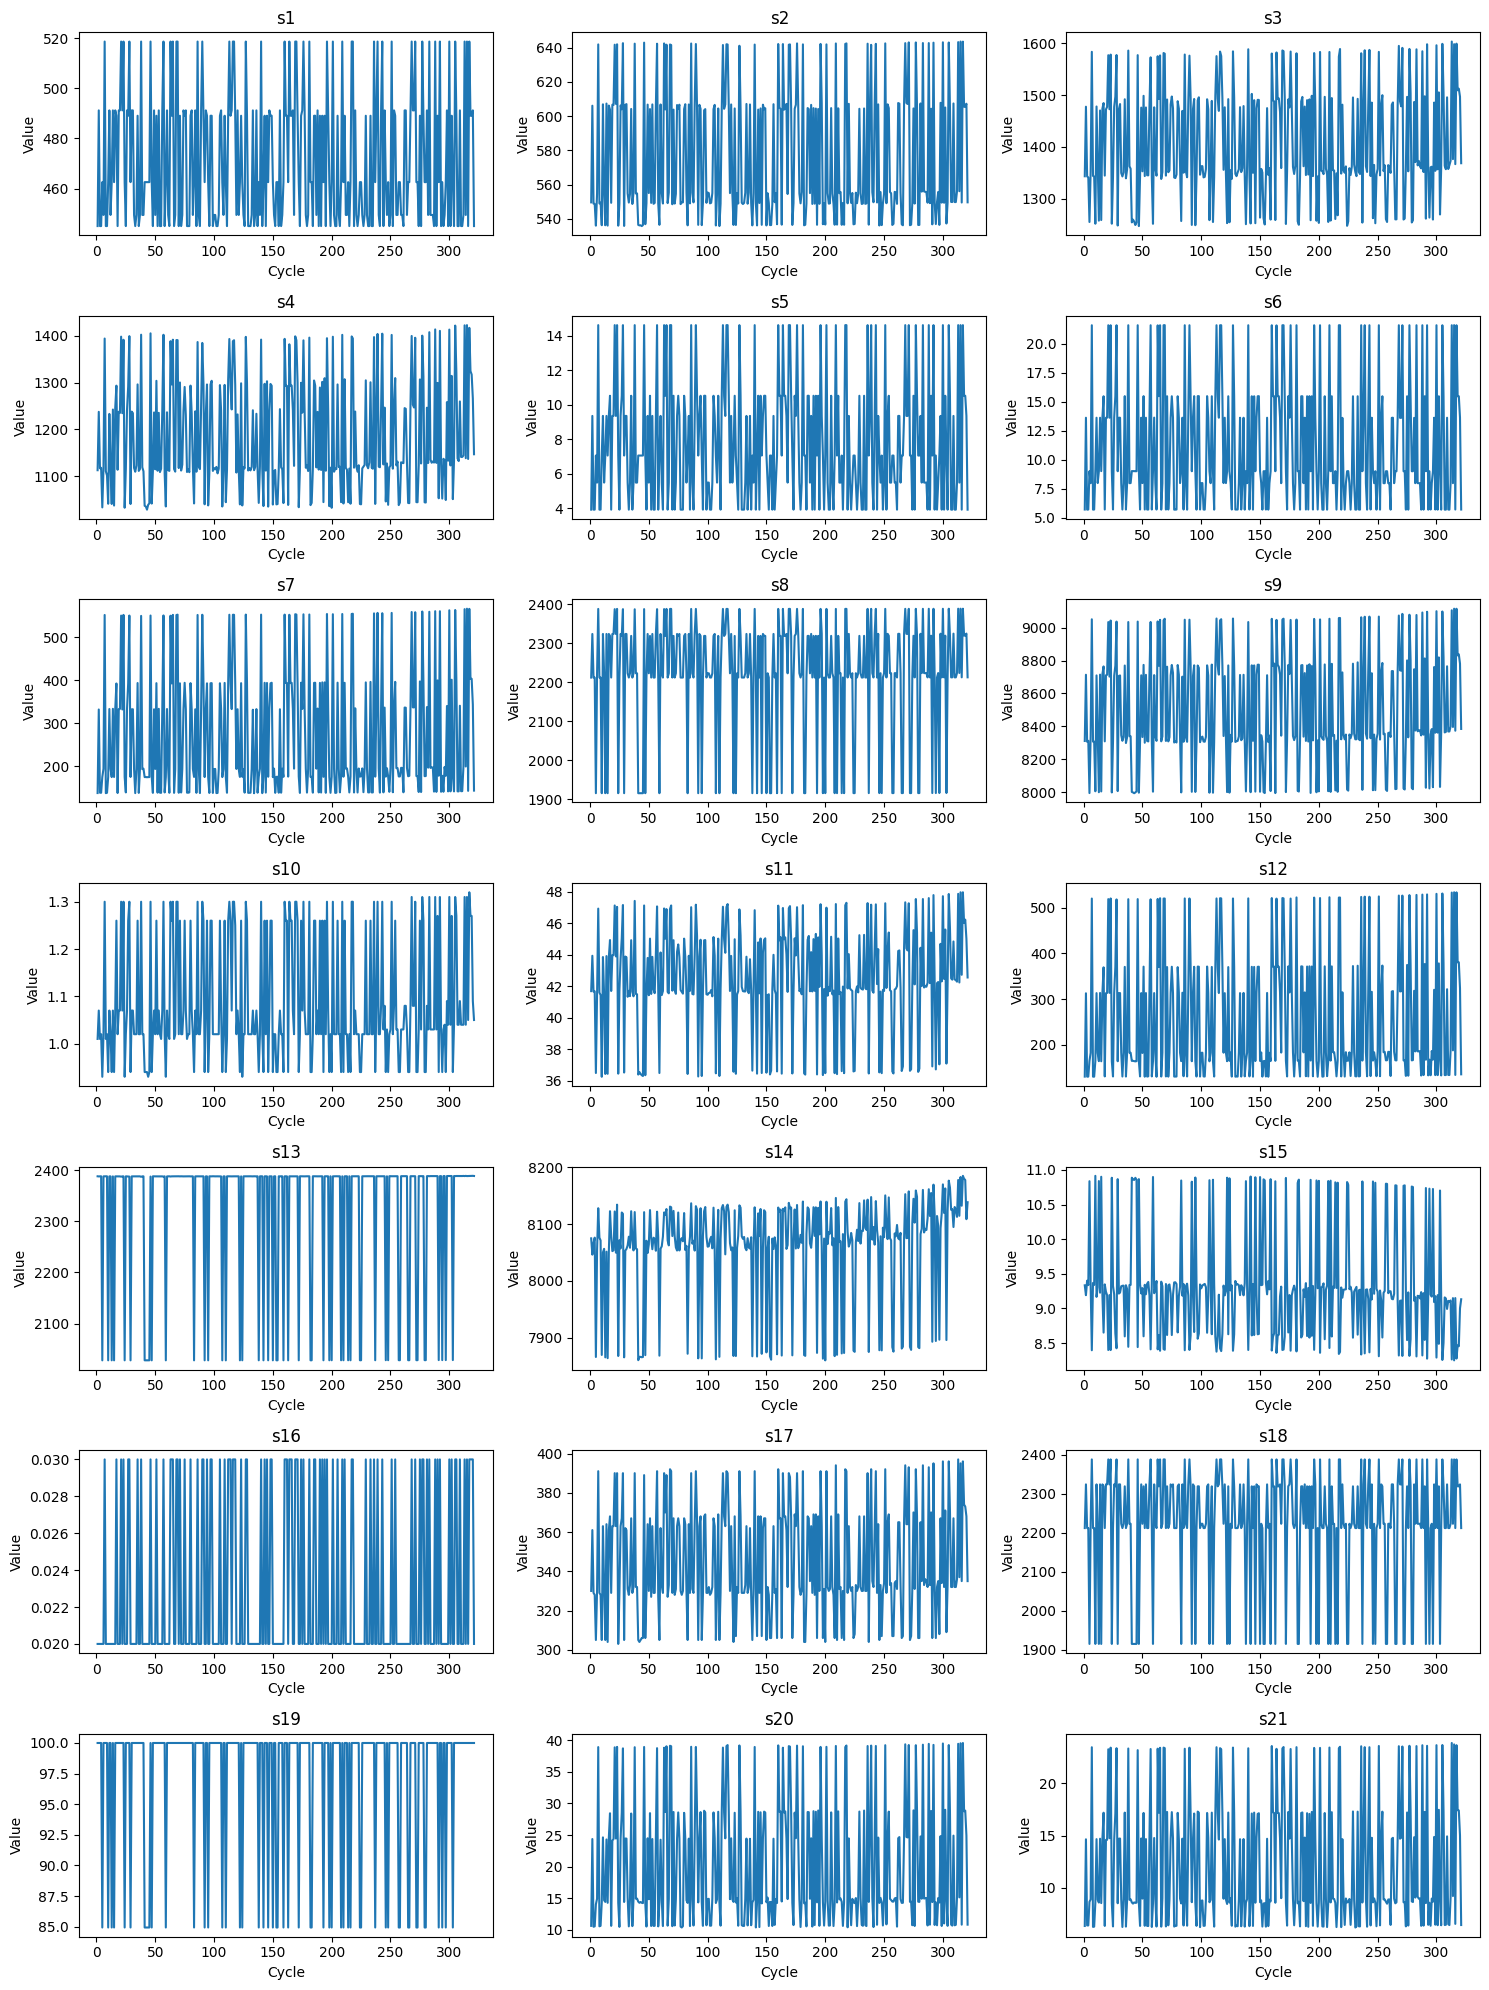

In [77]:
unit_to_plot = 1
unit_data = df[df['unit'] == unit_to_plot]

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

for i in range(21):
    col = f's{i+1}'
    axes[i].plot(unit_data['cycle'], unit_data[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

In [78]:
sensor_cols = [f's{i}' for i in range(1,22)]
sensor_std_per_unit = df.groupby('unit')[sensor_cols].std()
mean_std_across_units = sensor_std_per_unit.mean().sort_values()
print(mean_std_across_units)

s16      0.004691
s10      0.127723
s15      0.748847
s11      3.242456
s5       3.628623
s19      5.366243
s6       5.452820
s21      5.966584
s20      9.942698
s1      26.480009
s17     27.836150
s2      37.401791
s14     85.005095
s3     106.271580
s4     119.433446
s13    128.123358
s12    138.599953
s8     145.374304
s18    145.493216
s7     147.005779
s9     337.076600
dtype: float64


Все сенсоры полезны